Import Libraries and Load Dataset

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Preprocess the data

In [15]:
# Normalize the data
x_train = x_train/255.0
x_test = x_test/255.0

In [16]:
#Reshape to (28,28,1)
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

In [17]:
# One hot encode labels
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

Build the CNN Model

In [18]:
from tensorflow.keras import layers,models
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience =2)

In [20]:

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Train the Model

In [21]:
model.fit(x_train, y_train, epochs = 7, validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9344 - loss: 0.2112 - val_accuracy: 0.9847 - val_loss: 0.0517
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9755 - loss: 0.0814 - val_accuracy: 0.9882 - val_loss: 0.0356
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9811 - loss: 0.0622 - val_accuracy: 0.9910 - val_loss: 0.0272
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9837 - loss: 0.0530 - val_accuracy: 0.9901 - val_loss: 0.0292
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9862 - loss: 0.0470 - val_accuracy: 0.9924 - val_loss: 0.0226
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9882 - loss: 0.0412 - val_accuracy: 0.9931 - val_loss: 0.0200
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9888 - loss: 0.0361 - val_accuracy: 0.9933 - val_loss: 0.0218


Evaluate the Model - Training Data Plot

In [22]:
model.metrics_names

['loss', 'compile_metrics']

In [23]:
losses = pd.DataFrame(model.history.history)

In [24]:
losses

,accuracy,loss,val_accuracy,val_loss
0,0.934433,0.211217,0.9847,0.051723
1,0.975483,0.081358,0.9882,0.035623
2,0.981083,0.062176,0.9910,0.027179
3,0.983700,0.053003,0.9901,0.029227
4,0.986150,0.046954,0.9924,0.022597
5,0.988200,0.041213,0.9931,0.020018
6,0.988817,0.036102,0.9933,0.021827


Loss graph

<Axes: >

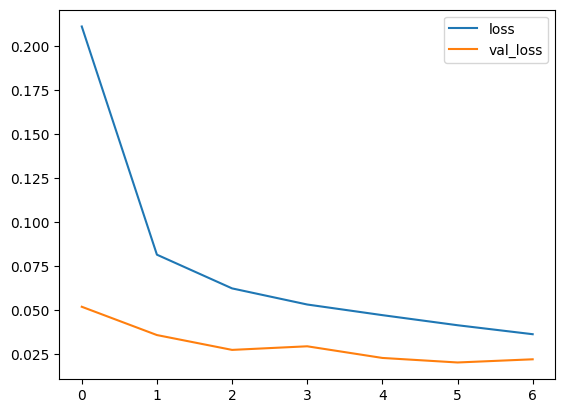

In [25]:
losses[['loss','val_loss']].plot()

The above graph represents the loss graph. The blue line is telling about the training loss and the orange line tells about the validation loss.Validation loss is slowly decreasing

Accuracy Plot

<Axes: >

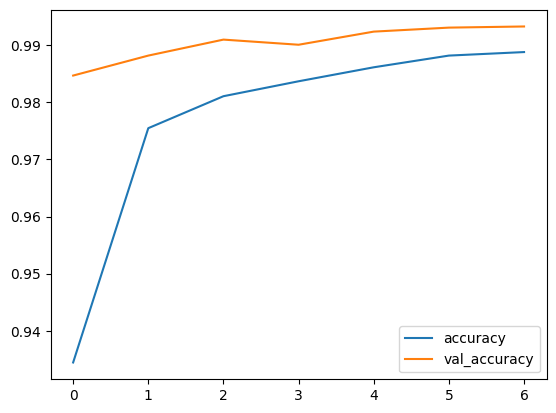

In [26]:
losses[['accuracy', 'val_accuracy']].plot()

Test Model Accuracy

In [27]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(test_loss, test_acc)
print(f"Test Accuracy:{test_acc*100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9933 - loss: 0.0218
0.021827491000294685 0.9933000206947327
Test Accuracy:99.33


Test with Custom Images

Custom Image -1

In [40]:
from tensorflow.keras.preprocessing import image

In [41]:
img = image.load_img('digit2.png', target_size=(28,28), color_mode='grayscale')

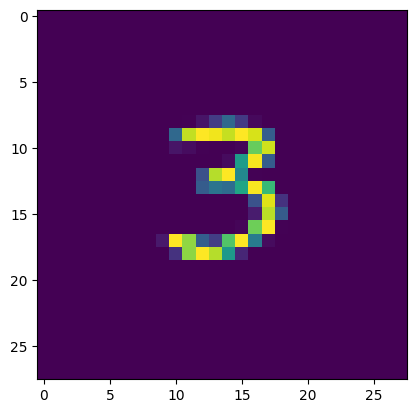

In [42]:
plt.imshow(img)

In [43]:
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [44]:
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Digit: 3


Second image

In [57]:
img = image.load_img('test1.png', target_size=(28,28), color_mode='grayscale')

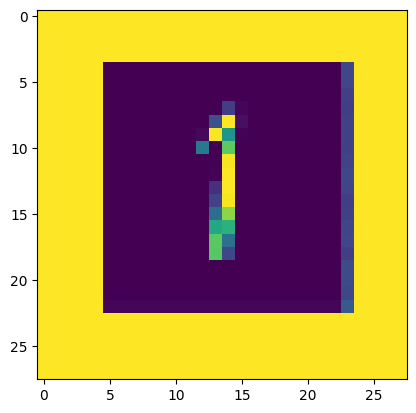

In [58]:
plt.imshow(img)

In [59]:
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [60]:
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Digit: 1


Third  custom Image

In [74]:
img = image.load_img('data1.png', target_size=(28,28), color_mode='grayscale')

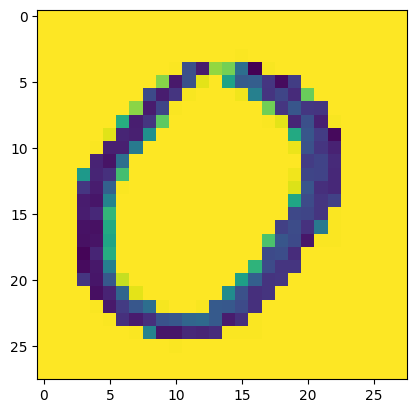

In [75]:
plt.imshow(img)

In [76]:
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [77]:
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Digit: 0
